# Model Optimization
## Breast Cancer Wisconsin (Diagnostic) — Stage 5

Improve the **best two** models identified in Stage 4 using
**hyperparameter tuning** with **cross-validation**, then compare results
**before vs after** and save the **final model**.

- Search: `GridSearchCV` (with `RandomizedSearchCV` used for the larger grid).
- Validation: **StratifiedKFold (5-fold)** cross-validation.
- Scoring: **F1 on the malignant class** (our priority metric).

## 1. Setup & Load Data

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, make_scorer,
    confusion_matrix, ConfusionMatrixDisplay)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
POS_LABEL = 0                       # malignant = positive
f1_malignant = make_scorer(f1_score, pos_label=POS_LABEL)

# Same reproducible split + scaling as Stages 2-3
df = pd.read_csv("breast_cancer_wisconsin.csv")
feature_cols = [c for c in df.columns if c not in ("target", "diagnosis")]
X, y = df[feature_cols], df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)
print("Data ready:", X_train_s.shape, X_test_s.shape)

Data ready: (455, 30) (114, 30)


## 2. Which two models are we optimizing?

In [2]:
top2_path = Path("reports/top2_models.json")
if top2_path.exists():
    top2 = json.loads(top2_path.read_text())
else:
    top2 = ["SVM", "Random Forest"]   # sensible fallback
print("Top-2 models from Stage 4:", top2)

baseline_metrics = pd.read_csv("reports/individual_model_metrics.csv",
                               index_col="Model").round(4)
baseline_metrics.loc[top2]

Top-2 models from Stage 4: ['SVM', 'XGBoost']


,Accuracy,Precision,Recall,F1-score
Model,,,,
SVM,0.9649,0.9318,0.9762,0.9535
XGBoost,0.9561,0.9744,0.9048,0.9383


## 3. Define Estimators + Hyperparameter Search Spaces

A search space is defined for every candidate model; we tune whichever two
Stage 4 selected. Grids are scaled-data appropriate.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search_space = {
    "SVM": {
        "estimator": SVC(probability=True, random_state=RANDOM_STATE,
                         class_weight="balanced"),
        "param_grid": {
            "C": [0.1, 0.5, 1, 5, 10, 50, 100],
            "gamma": ["scale", "auto", 0.001, 0.01, 0.1],
            "kernel": ["rbf", "linear"],
        },
        "search": "grid",
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=RANDOM_STATE,
                                            class_weight="balanced", n_jobs=-1),
        "param_grid": {
            "n_estimators": [200, 300, 500, 800],
            "max_depth": [None, 5, 8, 12],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt", "log2"],
        },
        "search": "random",
    },
    "XGBoost": {
        "estimator": XGBClassifier(eval_metric="logloss",
                                   random_state=RANDOM_STATE, n_jobs=-1),
        "param_grid": {
            "n_estimators": [200, 300, 500],
            "max_depth": [3, 4, 5, 6],
            "learning_rate": [0.01, 0.05, 0.1, 0.2],
            "subsample": [0.8, 0.9, 1.0],
            "colsample_bytree": [0.8, 0.9, 1.0],
        },
        "search": "random",
    },
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(random_state=RANDOM_STATE,
                                            class_weight="balanced"),
        "param_grid": {
            "criterion": ["gini", "entropy"],
            "max_depth": [None, 3, 5, 8, 12],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
        },
        "search": "grid",
    },
    "Naive Bayes": {
        "estimator": GaussianNB(),
        "param_grid": {"var_smoothing": np.logspace(-11, -1, 20)},
        "search": "grid",
    },
}
print("Search spaces defined for:", list(search_space.keys()))

Search spaces defined for: ['SVM', 'Random Forest', 'XGBoost', 'Decision Tree', 'Naive Bayes']


## 4. Run the Search (with 5-fold CV) for each of the Top-2

In [4]:
tuned = {}      # name -> fitted best estimator
search_info = {}

for name in top2:
    cfg = search_space[name]
    if cfg["search"] == "grid":
        search = GridSearchCV(cfg["estimator"], cfg["param_grid"],
                              scoring=f1_malignant, cv=cv, n_jobs=-1, verbose=0)
    else:
        search = RandomizedSearchCV(cfg["estimator"], cfg["param_grid"],
                                    n_iter=40, scoring=f1_malignant, cv=cv,
                                    n_jobs=-1, random_state=RANDOM_STATE, verbose=0)
    search.fit(X_train_s, y_train)
    tuned[name] = search.best_estimator_
    search_info[name] = {
        "best_params": search.best_params_,
        "best_cv_f1": search.best_score_,
    }
    print("=" * 55)
    print(name)
    print("  Best CV F1 (malignant):", round(search.best_score_, 4))
    print("  Best params:", search.best_params_)

SVM
  Best CV F1 (malignant): 0.9704
  Best params: {'C': 5, 'gamma': 0.01, 'kernel': 'rbf'}


C:\Users\acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


XGBoost
  Best CV F1 (malignant): 0.9647
  Best params: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


## 5. Before vs After — on the Held-out Test Set

In [5]:
def evaluate(model, X_te, y_te):
    yp = model.predict(X_te)
    return {
        "Accuracy":  accuracy_score(y_te, yp),
        "Precision": precision_score(y_te, yp, pos_label=POS_LABEL),
        "Recall":    recall_score(y_te, yp, pos_label=POS_LABEL),
        "F1-score":  f1_score(y_te, yp, pos_label=POS_LABEL),
    }

rows = []
for name in top2:
    before = baseline_metrics.loc[name].to_dict()
    after = evaluate(tuned[name], X_test_s, y_test)
    for metric in ["Accuracy", "Precision", "Recall", "F1-score"]:
        rows.append({
            "Model": name, "Metric": metric,
            "Before": round(before[metric], 4),
            "After":  round(after[metric], 4),
            "Delta":  round(after[metric] - before[metric], 4),
        })

ba = pd.DataFrame(rows)
ba_pivot = ba.pivot(index="Model", columns="Metric",
                    values=["Before", "After"]).round(4)
ba

,Model,Metric,Before,After,Delta
0,SVM,Accuracy,0.9649,0.9561,-0.0088
1,SVM,Precision,0.9318,0.9111,-0.0207
2,SVM,Recall,0.9762,0.9762,-0.0000
3,SVM,F1-score,0.9535,0.9425,-0.0110
4,XGBoost,Accuracy,0.9561,0.9649,0.0088
5,XGBoost,Precision,0.9744,0.9750,0.0006
6,XGBoost,Recall,0.9048,0.9286,0.0238
7,XGBoost,F1-score,0.9383,0.9512,0.0129


In [6]:
# Tidy before/after table per model
for name in top2:
    print("\n", "=" * 45, "\n", name)
    sub = ba[ba["Model"] == name].set_index("Metric")[["Before", "After", "Delta"]]
    print(sub)


 SVM
           Before   After   Delta
Metric                           
Accuracy   0.9649  0.9561 -0.0088
Precision  0.9318  0.9111 -0.0207
Recall     0.9762  0.9762 -0.0000
F1-score   0.9535  0.9425 -0.0110

 XGBoost
           Before   After   Delta
Metric                           
Accuracy   0.9561  0.9649  0.0088
Precision  0.9744  0.9750  0.0006
Recall     0.9048  0.9286  0.0238
F1-score   0.9383  0.9512  0.0129


### 5.1 Before vs After chart

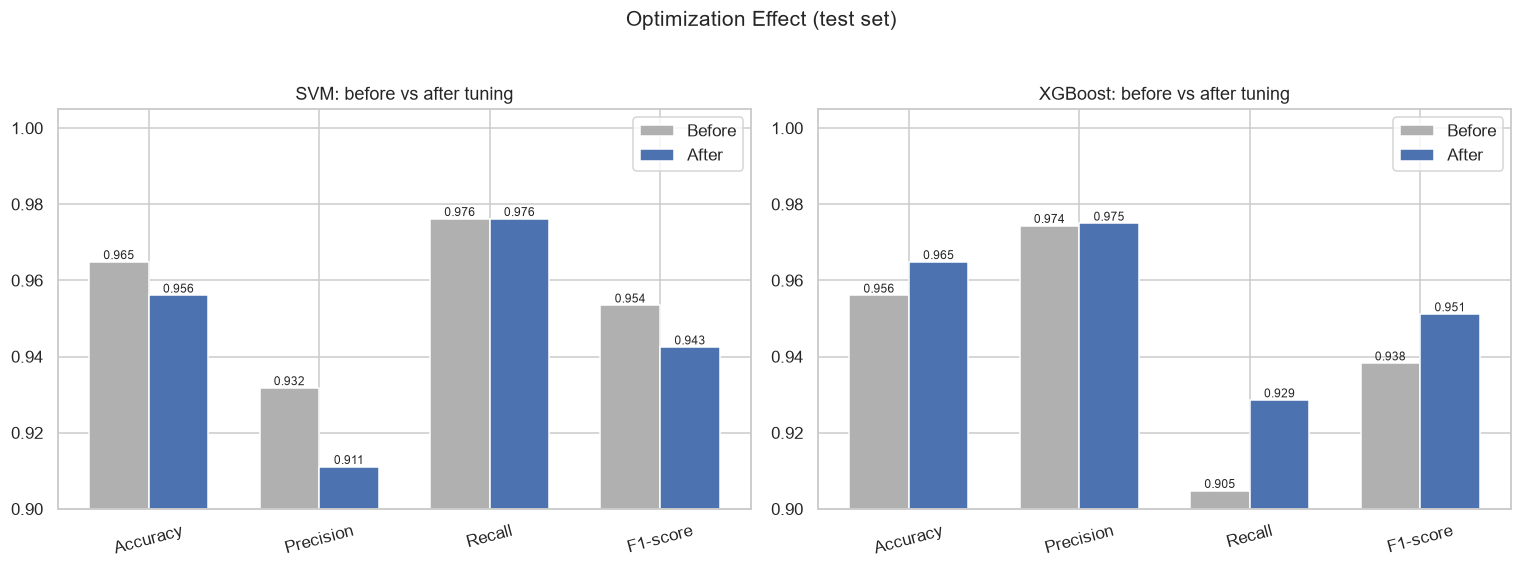

In [7]:
fig, axes = plt.subplots(1, len(top2), figsize=(7 * len(top2), 5), squeeze=False)
axes = axes[0]
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = np.arange(len(metrics))
w = 0.35
for ax, name in zip(axes, top2):
    sub = ba[ba["Model"] == name].set_index("Metric").loc[metrics]
    ax.bar(x - w/2, sub["Before"], w, label="Before", color="#B0B0B0")
    ax.bar(x + w/2, sub["After"], w, label="After",  color="#4C72B0")
    ax.set_xticks(x); ax.set_xticklabels(metrics, rotation=15)
    ax.set_ylim(0.9, 1.005)
    ax.set_title(f"{name}: before vs after tuning")
    ax.legend()
    for i, (b, a) in enumerate(zip(sub["Before"], sub["After"])):
        ax.annotate(f"{b:.3f}", (i - w/2, b), ha="center", va="bottom", fontsize=8)
        ax.annotate(f"{a:.3f}", (i + w/2, a), ha="center", va="bottom", fontsize=8)
plt.suptitle("Optimization Effect (test set)", y=1.03, fontsize=14)
plt.tight_layout()
plt.savefig("figures/13_before_after_tuning.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. Choose & Save the Final Model

In [8]:
# Pick the tuned model with the best test F1 (malignant), tie-break on recall.
final_scores = {}
for name in top2:
    m = evaluate(tuned[name], X_test_s, y_test)
    final_scores[name] = (m["F1-score"], m["Recall"], m["Accuracy"])

final_name = max(final_scores, key=lambda k: final_scores[k])
final_model = tuned[final_name]
final_metrics = evaluate(final_model, X_test_s, y_test)

print("Final model selected:", final_name)
print("Test metrics:", {k: round(v, 4) for k, v in final_metrics.items()})
print("Best params:", search_info[final_name]["best_params"])

Final model selected: XGBoost
Test metrics: {'Accuracy': 0.9649, 'Precision': 0.975, 'Recall': 0.9286, 'F1-score': 0.9512}
Best params: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


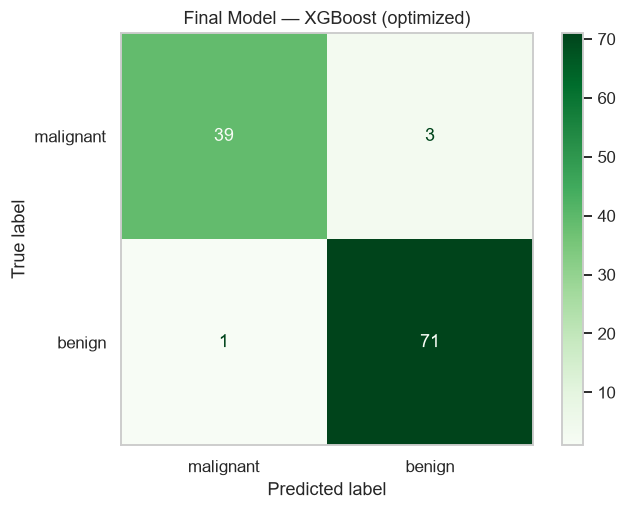

In [9]:
# Confusion matrix of the final model
cm = confusion_matrix(y_test, final_model.predict(X_test_s), labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=["malignant", "benign"]).plot(
    cmap="Greens", values_format="d")
plt.title(f"Final Model — {final_name} (optimized)")
plt.grid(False)
plt.tight_layout()
plt.savefig("figures/14_final_model_confusion.png", dpi=130, bbox_inches="tight")
plt.show()

In [10]:
# Save the final model bundled with its scaler + metadata, so it can score
# raw (unscaled) feature rows directly.
bundle = {
    "model": final_model,
    "scaler": scaler,
    "feature_cols": feature_cols,
    "positive_class": "malignant (0)",
    "model_name": final_name,
    "best_params": search_info[final_name]["best_params"],
    "test_metrics": final_metrics,
}
joblib.dump(bundle, "models/final_model.joblib")
print("Saved -> models/final_model.joblib")

Saved -> models/final_model.joblib


### 6.1 Sanity check — reload and predict

In [11]:
loaded = joblib.load("models/final_model.joblib")
mdl, scl, cols = loaded["model"], loaded["scaler"], loaded["feature_cols"]

# take 5 raw test rows, scale with the bundled scaler, predict
sample_raw = X_test.iloc[:5][cols]
pred = mdl.predict(scl.transform(sample_raw))
label = {0: "malignant", 1: "benign"}
print("Predictions:", [label[p] for p in pred])
print("Actual     :", [label[t] for t in y_test.iloc[:5]])
print("\nReloaded final model:", loaded["model_name"], "| params:", loaded["best_params"])

Predictions: ['malignant', 'benign', 'malignant', 'malignant', 'malignant']
Actual     : ['malignant', 'benign', 'malignant', 'benign', 'malignant']

Reloaded final model: XGBoost | params: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


## 7. Write the Performance Report

In [12]:
lines = ["# Model Optimization — Performance Report",
         "## Breast Cancer Wisconsin (Diagnostic) — Stage 5\n",
         "Tuning via GridSearchCV / RandomizedSearchCV with 5-fold "
         "StratifiedKFold cross-validation. Scoring = **F1 on malignant (0)**.\n",
         f"Optimized models: **{top2[0]}** and **{top2[1]}**.\n",
         "## Best Hyperparameters\n"]
for name in top2:
    lines.append(f"### {name}")
    lines.append(f"- Best CV F1: **{search_info[name]['best_cv_f1']:.4f}**")
    lines.append(f"- Best params: `{search_info[name]['best_params']}`\n")

lines.append("## Before vs After (test set)\n")
for name in top2:
    lines.append(f"### {name}")
    sub = ba[ba["Model"] == name].set_index("Metric")[["Before", "After", "Delta"]]
    lines.append(sub.to_markdown())
    lines.append("")

lines.append("## Final Model\n")
lines.append(f"**{final_name}** (optimized) was saved as `models/final_model.joblib`.\n")
lines.append(f"- Accuracy: **{final_metrics['Accuracy']:.4f}**")
lines.append(f"- Precision (malignant): **{final_metrics['Precision']:.4f}**")
lines.append(f"- Recall (malignant): **{final_metrics['Recall']:.4f}**")
lines.append(f"- F1-score (malignant): **{final_metrics['F1-score']:.4f}**")
lines.append(f"- Best params: `{search_info[final_name]['best_params']}`\n")

Path("reports/OPTIMIZATION_REPORT.md").write_text("\n".join(lines), encoding="utf-8")
print("Wrote reports/OPTIMIZATION_REPORT.md")

Wrote reports/OPTIMIZATION_REPORT.md


## 8. Summary

- Tuned the **top-2** models with **GridSearchCV / RandomizedSearchCV** and
  **5-fold stratified cross-validation**, optimizing **F1 on the malignant
  class**.
- Reported **best parameters** and **before vs after** metrics with a chart.
- Selected and **saved the final model** (`models/final_model.joblib`) bundled
  with its scaler, feature list and metadata, and verified it reloads and
  predicts.
- Wrote `reports/OPTIMIZATION_REPORT.md`.

**The full pipeline is complete:** data understanding → preprocessing →
individual models → comparison → optimization → saved final model.